# Training with Early Stopping: 30-Class EfficientNet-B0 (FIDS30)

Train EfficientNet-B0 from scratch with early stopping based on validation accuracy.
Saves the best model checkpoint and visualizes training/validation loss and accuracy curves.

In [3]:
import timm
import torch
import torch.nn as nn

NUM_CLASSES = 30
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES)

print(f"Model: {model.default_cfg['architecture']}")
print(f"Classifier head: {model.get_classifier()}")

Model: efficientnet_b0
Classifier head: Linear(in_features=1280, out_features=30, bias=True)


In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader

config = timm.data.resolve_model_data_config(model)
train_transform = timm.data.create_transform(**config, is_training=True)
val_transform = timm.data.create_transform(**config, is_training=False)

train_ds = datasets.ImageFolder("PrepData/Training", transform=train_transform)
val_ds = datasets.ImageFolder("PrepData/Validation", transform=val_transform)

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, num_workers=0, pin_memory=True)

print(f"Classes: {train_ds.classes}")
print(f"Training samples: {len(train_ds)}, Validation samples: {len(val_ds)}")

Classes: ['acerolas', 'apples', 'apricots', 'avocados', 'bananas', 'blackberries', 'blueberries', 'cantaloupes', 'cherries', 'coconuts', 'figs', 'grapefruits', 'grapes', 'guava', 'kiwifruit', 'lemons', 'limes', 'mangos', 'olives', 'oranges', 'passionfruit', 'peaches', 'pears', 'pineapples', 'plums', 'pomegranates', 'raspberries', 'strawberries', 'tomatoes', 'watermelons']
Training samples: 582, Validation samples: 194


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
print(f"Device: {device}")

Device: cuda


## Training Loop with Early Stopping

Stop training when validation accuracy does not improve for `patience` consecutive epochs.
The best model (by validation accuracy) is saved to disk.

In [6]:
from tqdm.auto import tqdm

MAX_EPOCHS = 100
PATIENCE = 3
SAVE_PATH = "fids30_classifier_30cls_b0.pth"

# History for plotting
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

best_val_acc = 0.0
epochs_without_improvement = 0

for epoch in range(MAX_EPOCHS):
    # --- Training ---
    model.train()
    train_loss = 0.0
    train_correct = 0
    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{MAX_EPOCHS} [train]"):
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()

    avg_train_loss = train_loss / len(train_loader)
    train_acc = 100 * train_correct / len(train_ds)

    # --- Validation ---
    model.eval()
    val_loss = 0.0
    val_correct = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()

    avg_val_loss = val_loss / len(val_loader)
    val_acc = 100 * val_correct / len(val_ds)

    # Record history
    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}: Train Loss={avg_train_loss:.4f}, Train Acc={train_acc:.2f}%, "
          f"Val Loss={avg_val_loss:.4f}, Val Acc={val_acc:.2f}%")

    # Early stopping check
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  -> New best model saved ({val_acc:.2f}%)")
    else:
        epochs_without_improvement += 1
        print(f"  -> No improvement for {epochs_without_improvement}/{PATIENCE} epochs")

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}. Best Val Acc: {best_val_acc:.2f}%")
        break
else:
    print(f"\nReached max epochs ({MAX_EPOCHS}). Best Val Acc: {best_val_acc:.2f}%")

# Reload best model
model.load_state_dict(torch.load(SAVE_PATH, map_location=device))
print(f"Loaded best model from {SAVE_PATH}")

Epoch 1/100 [train]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1: Train Loss=3.9108, Train Acc=4.98%, Val Loss=3.2233, Val Acc=17.53%
  -> New best model saved (17.53%)


Epoch 2/100 [train]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 2: Train Loss=2.7744, Train Acc=21.13%, Val Loss=2.5270, Val Acc=36.08%
  -> New best model saved (36.08%)


Epoch 3/100 [train]:   0%|          | 0/10 [00:00<?, ?it/s]

...

Epoch 26: Train Loss=0.1558, Train Acc=96.74%, Val Loss=0.4133, Val Acc=86.60%
  -> No improvement for 2/4 epochs


Epoch 27/100 [train]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 27: Train Loss=0.2091, Train Acc=96.22%, Val Loss=0.4048, Val Acc=86.08%
  -> No improvement for 3/4 epochs


Epoch 28/100 [train]:   0%|          | 0/10 [00:00<?, ?it/s]

Epoch 28: Train Loss=0.1591, Train Acc=96.74%, Val Loss=0.3885, Val Acc=87.63%
  -> No improvement for 4/4 epochs

Early stopping at epoch 28. Best Val Acc: 88.66%
Loaded best model from fids30_classifier_30cls_b0.pth


## Training Curves

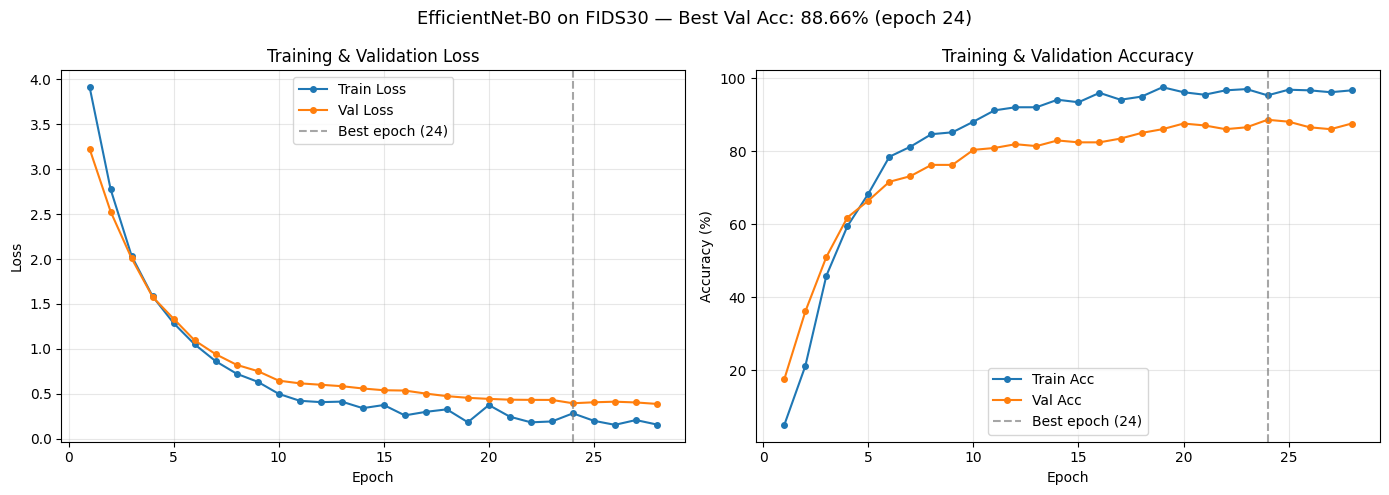

In [7]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)
best_epoch = history["val_acc"].index(max(history["val_acc"])) + 1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(epochs_range, history["train_loss"], label="Train Loss", marker='o', markersize=4)
ax1.plot(epochs_range, history["val_loss"], label="Val Loss", marker='o', markersize=4)
ax1.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch})")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, history["train_acc"], label="Train Acc", marker='o', markersize=4)
ax2.plot(epochs_range, history["val_acc"], label="Val Acc", marker='o', markersize=4)
ax2.axvline(x=best_epoch, color='gray', linestyle='--', alpha=0.7, label=f"Best epoch ({best_epoch})")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Training & Validation Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.suptitle(f"EfficientNet-B0 on FIDS30 — Best Val Acc: {best_val_acc:.2f}% (epoch {best_epoch})", fontsize=13)
plt.tight_layout()
plt.show()